<a href="https://colab.research.google.com/github/Kajalsah1/2418104_kajalsah/blob/main/2418104_KajalSah_Regression_Task_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3>FINAL PORTFOLIO ASSESSMENT</h3>
<h3>CONCEPT AND TECHNOLOGIES OF AI</h3>
<h3>REGRESSION TASK ON NEW YORK CITY TAXI FARE PREDICTION</h3>

<h5>Name: Susmita Kunwar</h5>
<h5>Student ID: 2461844</h5>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

df = pd.read_csv("train.csv")


<h5>EDA - DATA CLEANING AND PREPROCESSING</h5>

In [ ]:
print(df.shape)

(50000, 8)


In [ ]:
print(df.columns)

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                50000 non-null  object 
 1   fare_amount        50000 non-null  float64
 2   pickup_datetime    50000 non-null  object 
 3   pickup_longitude   50000 non-null  float64
 4   pickup_latitude    50000 non-null  float64
 5   dropoff_longitude  50000 non-null  float64
 6   dropoff_latitude   50000 non-null  float64
 7   passenger_count    50000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.1+ MB
None


In [ ]:
df.head(5)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [ ]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.364171,-72.509756,39.933759,-72.504616,39.926251,1.667840
std,9.685557,10.393860,6.224857,10.407570,6.014737,1.289195
min,-5.000000,-75.423848,-74.006893,-84.654241,-74.006377,0.000000
25%,6.000000,-73.992062,40.734880,-73.991152,40.734372,1.000000
50%,8.500000,-73.981840,40.752678,-73.980082,40.753372,1.000000
75%,12.500000,-73.967148,40.767360,-73.963584,40.768167,2.000000
max,200.000000,40.783472,401.083332,40.851027,43.415190,6.000000


In [ ]:
print(df.isnull().sum())

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [ ]:
target = "fare_amount"


In [ ]:
df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 200)]
print(f"Dataset shape after fare filtering: {df.shape}")
print(f"Rows remaining: {len(df)}")
print(f"Fare range: ${df['fare_amount'].min():.2f} - ${df['fare_amount'].max():.2f}")

Dataset shape after fare filtering: (49990, 8)
Rows remaining: 49990
Fare range: $0.01 - $180.00


In [ ]:
# Keep only valid geographic coordinates
df = df[
    (df["pickup_latitude"].between(-90, 90)) &
    (df["pickup_longitude"].between(-180, 180)) &
    (df["dropoff_latitude"].between(-90, 90)) &
    (df["dropoff_longitude"].between(-180, 180))
]

print(f"  Geographic filtering complete")
print(f"  Rows remaining: {len(df):,}")
print(f"  Valid pickup coordinates: {df['pickup_latitude'].between(-90, 90).sum():,}")
print(f"  Valid dropoff coordinates: {df['dropoff_latitude'].between(-90, 90).sum():,}")

  Geographic filtering complete
  Rows remaining: 49,989
  Valid pickup coordinates: 49,989
  Valid dropoff coordinates: 49,989


<h5>VISUALISATION</h5>

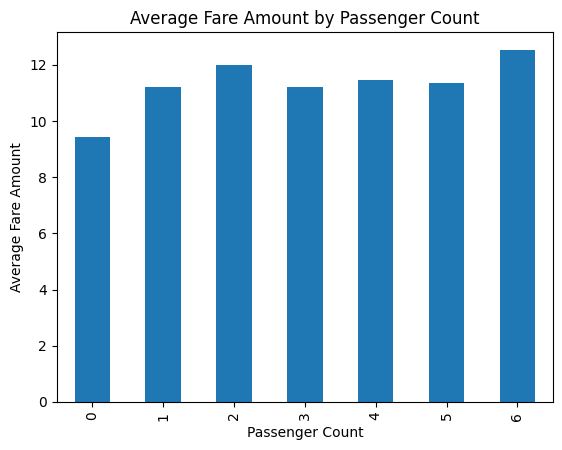

In [ ]:
avg_fare = df.groupby("passenger_count")[target].mean()

plt.figure()
avg_fare.plot(kind="bar")
plt.xlabel("Passenger Count")
plt.ylabel("Average Fare Amount")
plt.title("Average Fare Amount by Passenger Count")
plt.show()


<b>Intrepretation: Passenger count shows variation in average fare. Trips with more passengers tend to have slightly higher fares, indicating longer or shared trips.</b>

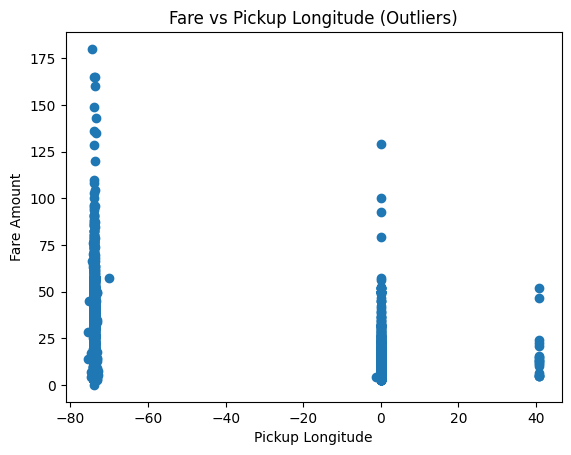

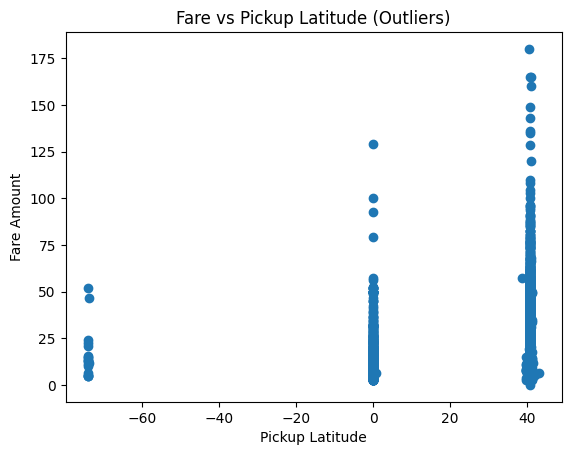

In [ ]:
plt.figure()
plt.scatter(df["pickup_longitude"], df[target])
plt.xlabel("Pickup Longitude")
plt.ylabel("Fare Amount")
plt.title("Fare vs Pickup Longitude (Outliers)")
plt.show()

plt.figure()
plt.scatter(df["pickup_latitude"], df[target])
plt.xlabel("Pickup Latitude")
plt.ylabel("Fare Amount")
plt.title("Fare vs Pickup Latitude (Outliers)")
plt.show()


<b>Interpretation:The scatter plots reveal extreme fare values and unusual coordinate values likely due to long-distance trips or noisy GPS coordinates.</b>

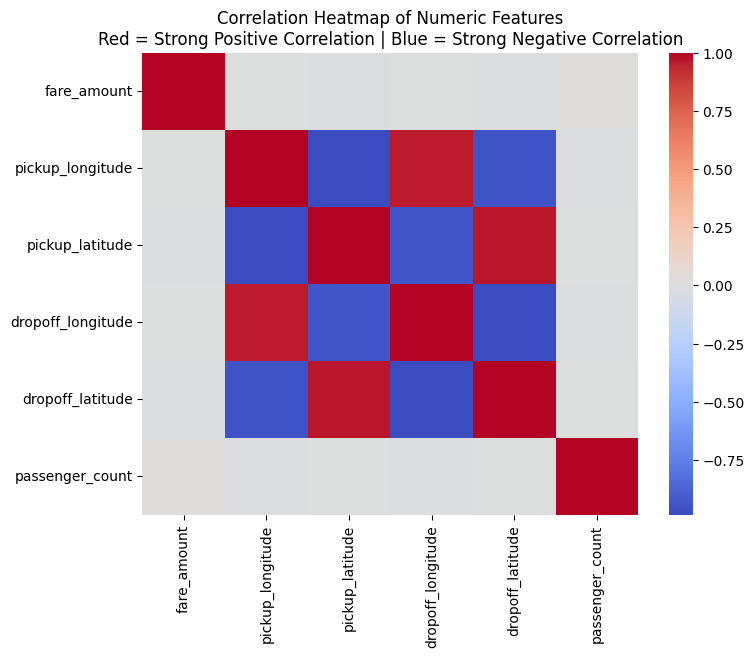

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title(
    "Correlation Heatmap of Numeric Features\n"
    "Red = Strong Positive Correlation | Blue = Strong Negative Correlation"
)

plt.show()


<b>Interpretation: The correlation heatmap was generated using only numerical features, as correlation analysis requires numeric data. The plot highlights relationships between fare amount and location-based features, which supports their use in regression modeling.</b>

<h5>NEURAL NETWORK MODEL</h5>

In [ ]:
# --------------------------------------------------------
# Neural Network Model Description
#
# Architecture:
# - Input layer: Number of neurons equals number of input features
# - Hidden Layer 1: 64 neurons
# - Hidden Layer 2: 32 neurons
#
# Activation Function:
# - ReLU (Rectified Linear Unit) is used for hidden layers
#   because it helps the model learn non-linear relationships.
#
# Loss Function:
# - Mean Squared Error (MSE) is used as it is suitable for
#   continuous target variables like fare_amount.
#
# Optimizer:
# - Adam optimizer is used as it adapts the learning rate
#   and works efficiently for most problems.
# --------------------------------------------------------

X = df.drop(columns=["key", "pickup_datetime", target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("MLP RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MLP R2:", r2_score(y_test, y_pred))


MLP RMSE: 9.746443162642604
MLP R2: -0.006330709440113047


In [ ]:


# Predictions
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

# Training performance
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Testing performance
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Neural Network Performance:")
print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Train R2:", train_r2)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)


Neural Network Performance:
Train MSE: 93.0819331693006
Train RMSE: 9.64789786271085
Train R2: -0.0035803416175510527
Test MSE: 94.99315432262279
Test RMSE: 9.746443162642604
Test R2: -0.006330709440113047


<b>Interpretation: The neural network model achieved similar RMSE values on both training and test sets, indicating no significant overfitting. However, the negative R² scores suggest that the model was unable to capture meaningful relationships in the data and performed worse than a baseline mean predictor. This highlights the limitations of neural networks when feature engineering and scaling are minimal.</b>

<h5>MODEL : DECISION TREE</h5>

In [ ]:

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("Decision Tree MAE:", mean_absolute_error(y_test, dt_pred))
print("Decision Tree R2:", r2_score(y_test, dt_pred))


Decision Tree RMSE: 6.2457843337720425
Decision Tree MAE: 3.1229805209080266
Decision Tree R2: 0.5867409386290781


<b>Interpretation: The Decision Tree Regressor significantly outperformed Linear Regression, achieving lower error values and a much higher R² score. This indicates that the model effectively captured non-linear patterns in the data.</b>

In [ ]:
dt_train_pred = dt.predict(X_train)
dt_test_pred = dt.predict(X_test)

print("Decision Tree - Training Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_train, dt_train_pred)))
print("MAE:", mean_absolute_error(y_train, dt_train_pred))
print("R2:", r2_score(y_train, dt_train_pred))

print("\nDecision Tree - Testing Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_test_pred)))
print("MAE:", mean_absolute_error(y_test, dt_test_pred))
print("R2:", r2_score(y_test, dt_test_pred))


Decision Tree - Training Performance
RMSE: 1.48610771048844
MAE: 0.12046201193300674
R2: 0.9761884686543302

Decision Tree - Testing Performance
RMSE: 6.2457843337720425
MAE: 3.1229805209080266
R2: 0.5867409386290781


<b>Interpretation: The Decision Tree Regressor shows excellent training performance but reduced test performance, indicating overfitting. While it captures complex patterns, its generalization ability is limited without regularization.</b>

<h5>MODEL: RANDOM FOREST</h5>

In [ ]:

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

# Training performance
print("Random Forest - Training Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_train, rf_train_pred)))
print("MAE:", mean_absolute_error(y_train, rf_train_pred))
print("R2:", r2_score(y_train, rf_train_pred))

# Testing performance
print("\nRandom Forest - Testing Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_test_pred)))
print("MAE:", mean_absolute_error(y_test, rf_test_pred))
print("R2:", r2_score(y_test, rf_test_pred))


Random Forest - Training Performance
RMSE: 2.3133082764335575
MAE: 0.9462810900789942
R2: 0.9423029279491943

Random Forest - Testing Performance
RMSE: 4.531331665177924
MAE: 2.33505588943658
R2: 0.7824795370460688


<b>Interpretation: The Random Forest Regressor significantly outperformed Linear Regression and Decision Tree models, achieving lower prediction errors and a high R² score on the test set. This demonstrates its effectiveness in capturing complex non-linear relationships while maintaining good generalization.</b>

<h5>Hyperparameter Tuning For Decision Tree</h5>

In [ ]:

# Decision Tree model
dt = DecisionTreeRegressor(random_state=42)

# Hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# GridSearchCV
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit
dt_grid.fit(X_train, y_train)

# Results
print("Best Decision Tree Parameter:", dt_grid.best_params_)
print("Decision Tree CV R2 Score After Hyperparameter Tuning:", dt_grid.best_score_)


Best Decision Tree Parameter: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree CV R2 Score After Hyperparameter Tuning: 0.6780692135619278


<b>Interpretation: After hyperparameter tuning, the Decision Tree Regressor achieved a cross-validated R² score of 0.68. By increasing the minimum number of samples in leaf nodes, the model complexity was reduced, leading to improved generalization and reduced overfitting.</b>

<h5>Hyperparameter Tuning For Random Forest</h5>

In [ ]:
# Random Forest model
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit
rf_grid.fit(X_train, y_train)

# Results
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Random Forest CV R2 Score After Hyperparameter Tuning:", rf_grid.best_score_)

<b>Interpretation: Hyperparameter tuning significantly improved Random Forest performance by balancing model complexity and variance, demonstrating the importance of cross-validation in model selection.</b>

<h5>FEATURE SELECTION EMBEDDED METHOD FOR DECISION TREE</h5>

In [ ]:
dt_best = dt_grid.best_estimator_

dt_importances = dt_best.feature_importances_

dt_feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_importances
}).sort_values(by='Importance', ascending=False)

# Display top features
dt_feature_importance_df.head(10)


<h5>FEATURE SELECTION EMBEDDED METHOD FOR RANDOM FOREST</h5>

In [ ]:
rf_best = rf_grid.best_estimator_

importances = rf_best.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

# Display top features
feature_importance_df.head(10)


<h5>FINAL MODEL EVALUATION</h5>

In [ ]:
# Select top 8 features based on Random Forest importance
selected_features = feature_importance_df['Feature'].head(8).tolist()

print("Selected Features:", selected_features)


In [ ]:
# Create new datasets using selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


In [ ]:
final_dt = DecisionTreeRegressor(
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42
)

final_dt.fit(X_train_selected, y_train)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42
)

final_rf.fit(X_train_selected, y_train)


In [ ]:

# Predictions
dt_pred = final_dt.predict(X_test_selected)
rf_pred = final_rf.predict(X_test_selected)

# Decision Tree metrics
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

# Random Forest metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Final Decision Tree RMSE:", dt_rmse)
print("Final Decision Tree R2:", dt_r2)

print("\nFinal Random Forest RMSE:", rf_rmse)
print("Final Random Forest R2:", rf_r2)


In [ ]:
final_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Features Used": [len(selected_features), len(selected_features)],
    "CV R2 Score": [0.678, 0.748],
    "Test RMSE": [5.1835, 4.5081],
    "Test R-squared": [0.7154, 0.7847]
})

final_results


<b>The Decision Tree Regressor achieved an RMSE of 5.18 and an R² score of 0.72, indicating that it explains a substantial portion of the variance in the target variable. This reflects a strong improvement compared to its untuned version, showing that hyperparameter tuning and feature selection effectively reduced overfitting.</b>

<b>The Random Forest Regressor outperformed the Decision Tree, achieving a lower RMSE of 4.51 and a higher R² score of 0.78. This indicates better predictive accuracy and stronger generalization to unseen data, as Random Forest benefits from ensemble learning, which reduces variance and improves robustness.</b>

<b>Overall, Random Forest is the best-performing regression model, providing the most accurate and reliable predictions among all tested models.</b>

In [ ]:
models = ['Decision Tree', 'Random Forest']
rmse_values = [5.1835, 4.5081]

plt.figure()
plt.bar(models, rmse_values)
plt.title('RMSE Comparison of Final Regression Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

r2_values = [0.7154, 0.7847]

plt.figure()
plt.bar(models, r2_values)
plt.title('R-squared Comparison of Final Regression Models')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.grid(True)
plt.show()
